In [173]:
#Menghubungkan colab dengan google drive
from google.colab import drive

drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
#Memanggil data set lewat g.drive
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/SEMESTER 3/Machine Lerning/Praktikum02/data/500_Person_Gender_Height_Weight_Index (1).csv')
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [175]:
#Membaca file csv menggunakan pandas
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/SEMESTER 3/Machine Lerning/Praktikum02/data/500_Person_Gender_Height_Weight_Index (1).csv')
df

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [176]:
# Menghtung dan memnampilkan semua dtaa dalam frame
#Mencari info data pada file (tipe datanya, non nul count data, nama kolom)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [177]:
#Menghitung mean semua kolom numerik
df['Height'].mean()

np.float64(169.944)

In [178]:
#Menghitung median semua kolom numerik

df['Height'].median()

170.5

In [179]:
#Mencari modus (Hati-hati bisa lebih dari 1)
df['Height'].mode()

,Height
0,188


In [180]:
df.var(numeric_only=True)

,0
Height,268.149162
Weight,1048.633267
Index,1.836168


In [181]:
q1 = df['Height'].quantile(0.25)

print("Q1 : ", q1)

q3 = df['Height'].quantile(0.75)

print("Q3 : ", q3)

iqr = q3 - q1

print("IQR : ", iqr)

Q1 :  156.0
Q3 :  184.0
IQR :  28.0


In [182]:
df.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


<Axes: >

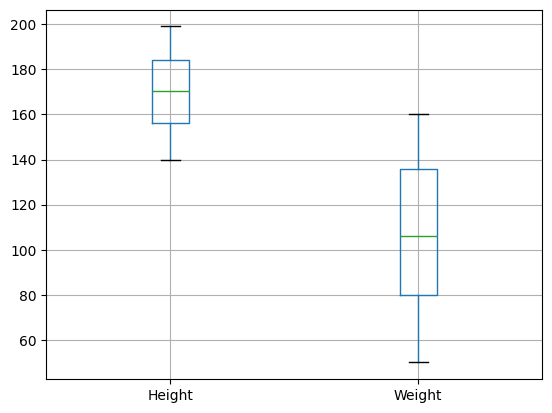

In [183]:
df.boxplot(column=['Height', 'Weight'])

<function matplotlib.pyplot.show(close=None, block=None)>

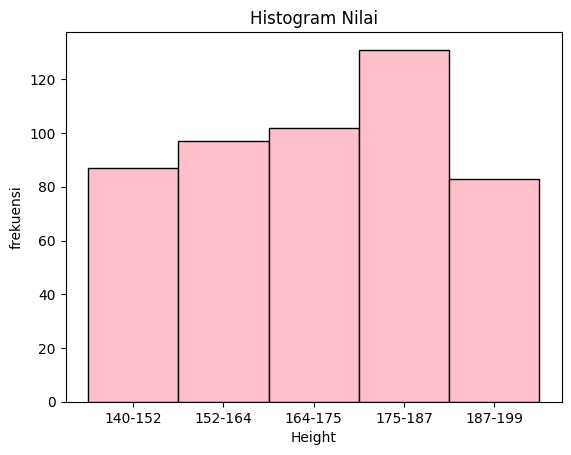

In [184]:
import matplotlib.pyplot as plt

#Ambil data Height
data_height = df["Height"]

#Buat Histrogram
n, bins, patches = plt.hist(data_height, bins=5, color='pink', edgecolor='black')

#Tambahkan Label
plt.title('Histogram Nilai')
plt.xlabel('Height')
plt.ylabel('frekuensi')

#Tampilkan Rentang frekuensi di sumbu x
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, ['{:.0f}-{:.0f}'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)])

#Tampilan histogram
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

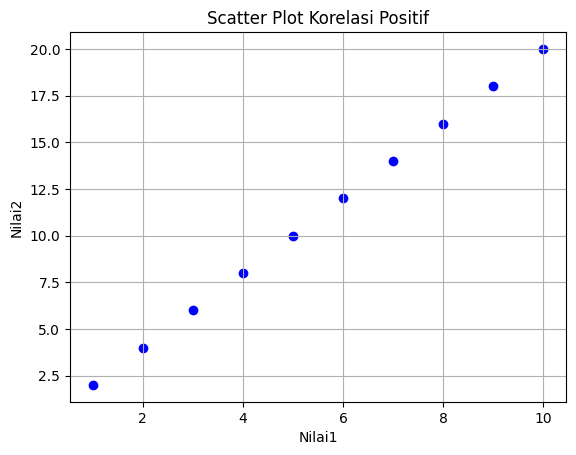

In [185]:
#Hubungan antar Variabel
import matplotlib.pyplot as plt
data = {
    'Nilai1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai2': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
}

df2 = pd.DataFrame(data)

#Buat catter plot
plt.scatter(df2['Nilai1'], df2['Nilai2'], color="blue", marker='o')

#Tambahkan label
plt.title('Scatter Plot Korelasi Positif')
plt.xlabel('Nilai1')
plt.ylabel('Nilai2')

#Tambahkan grid
plt.grid(True)

#Tampilan Plot
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

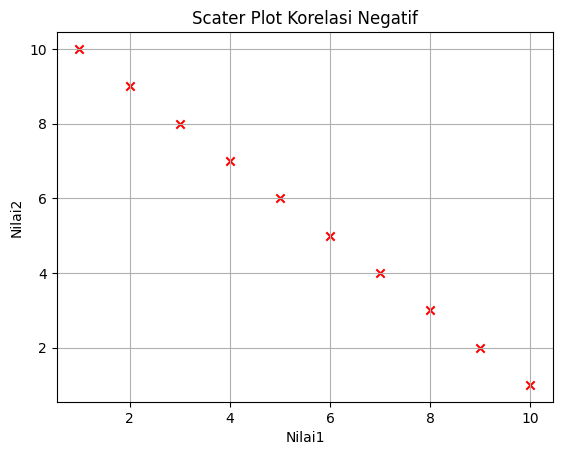

In [186]:
import pandas as pd
import matplotlib.pyplot as plt

#Contoh daftar Frame
data = {
    'Nilai1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai2': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
}

df3 = pd.DataFrame(data)

#Buat Scatter plot
plt.scatter(df3['Nilai1'], df3['Nilai2'], color="red", marker="x")

#Tambahkan label
plt.title('Scater Plot Korelasi Negatif')
plt.xlabel('Nilai1')
plt.ylabel('Nilai2')

#Tambahkan grid
plt.grid(True)

#Tampilan Plot
plt.show





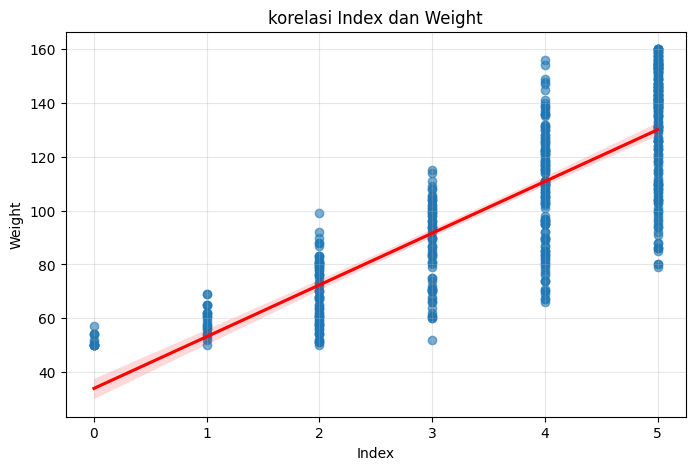

In [187]:
#Scatter plot + garis regresi
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Index',
    y='Weight',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title('korelasi Index dan Weight')
plt.xlabel('Index')
plt.ylabel('Weight')
plt.grid(True, alpha=0.3)

plt.show()

In [188]:
#Menghitung matreiks korelasi untuk semua kolom numerik
correlation_matrix = df[['Index', 'Weight']].corr(numeric_only=True)

#Menampilkam matriks korelasi
print("Matriks Korelasi:")
print(correlation_matrix)

Matriks Korelasi:
           Index    Weight
Index   1.000000  0.804569
Weight  0.804569  1.000000


In [189]:
#1. Data Cleaning
# Menubah data bernilai string / object menjadi numerik
df_encoded = pd.get_dummies(
    df,
    columns=['Gender'],
    dtype=int
)
print("data setelah One-Hot Encoding:")
display(df_encoded)

data setelah One-Hot Encoding:


,Height,Weight,Index,Gender_Female,Gender_Male
0,174,96,4,0,1
1,189,87,2,0,1
2,185,110,4,1,0
3,195,104,3,1,0
4,149,61,3,0,1
...,...,...,...,...,...
495,150,153,5,1,0
496,184,121,4,1,0
497,141,136,5,1,0
498,150,95,5,0,1


In [190]:
#2. Memecahkan Variabel X dann Y

x = df_encoded.drop('Index', axis=1)
y = df_encoded['Index']

print("Data X:")
display(x.head())

print("Data Y:")
display(y.head())

Data X:


,Height,Weight,Gender_Female,Gender_Male
0,174,96,0,1
1,189,87,0,1
2,185,110,1,0
3,195,104,1,0
4,149,61,0,1


Data Y:


,Index
0,4
1,2
2,4
3,3
4,3


In [191]:
# Memecahkan Data Train, Test, dan Validation
from sklearn.model_selection import train_test_split

#Pisahkan Data Testing
x_train_val, x_test, y_tain_val, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

#Pisahkan Training dan Validation Validation = 10% dari data training
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val,
    y_tain_val,
    test_size=0.10,
    random_state=42
)

print("Jumlah Data:")
print(f"Training : {len(x_train)} data")
print(f"Validation : {len(x_val)} data")
print(f"Testing : {len(x_test)} data")

print("\n5 Baris Data Training:")
display(x_train.head())

print("\n5 Baris Data Validation:")
display(x_val.head())

print("\n5 Baris Data Testing:")
display(x_test.head())

Jumlah Data:
Training : 360 data
Validation : 40 data
Testing : 100 data

5 Baris Data Training:


,Height,Weight,Gender_Female,Gender_Male
151,140,52,0,1
357,186,143,1,0
373,163,63,1,0
227,188,123,0,1
404,193,130,0,1



5 Baris Data Validation:


,Height,Weight,Gender_Female,Gender_Male
120,168,87,1,0
128,182,151,0,1
271,152,103,0,1
349,157,60,1,0
272,187,121,1,0



5 Baris Data Testing:


,Height,Weight,Gender_Female,Gender_Male
361,161,103,0,1
73,180,75,0,1
374,174,95,0,1
155,179,103,1,0
104,192,140,1,0


In [192]:
from sklearn.model_selection import train_test_split

# Pisahkan Data Testing
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Pisahkan Training dan Validation (10% dari data training)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.10, random_state=42
)

print("Jumlah Data:")
print(f"Training : {len(x_train)} data")
print(f"Validation : {len(x_val)} data")
print(f"Testing : {len(x_test)} data")

print("\n5 Baris Data Training:")
display(x_train.head())

print("\n5 Baris Data Validation:")
display(x_val.head())

print("\n5 Baris Data Testing:")
display(x_test.head())

Jumlah Data:
Training : 360 data
Validation : 40 data
Testing : 100 data

5 Baris Data Training:


,Height,Weight,Gender_Female,Gender_Male
151,140,52,0,1
357,186,143,1,0
373,163,63,1,0
227,188,123,0,1
404,193,130,0,1



5 Baris Data Validation:


,Height,Weight,Gender_Female,Gender_Male
120,168,87,1,0
128,182,151,0,1
271,152,103,0,1
349,157,60,1,0
272,187,121,1,0



5 Baris Data Testing:


,Height,Weight,Gender_Female,Gender_Male
361,161,103,0,1
73,180,75,0,1
374,174,95,0,1
155,179,103,1,0
104,192,140,1,0


In [194]:
print("\nCek jumlah baris data duplikat:")
print("Jumlah duplikat:", df.duplicated().sum())




Cek jumlah baris data duplikat:
Jumlah duplikat: 11


In [195]:
df = df.drop_duplicates()

In [196]:
df.shape

(489, 4)

In [197]:
print("\nBentuk dataset (baris, kolom):", df.shape)


Bentuk dataset (baris, kolom): (489, 4)


In [198]:
import pandas as pd

# Memuat ulang dataset 500_Person_Gender_Height_Weight_Index (1).csv
df_person = pd.read_csv('/content/drive/MyDrive/SEMESTER 3/Machine Lerning/Praktikum02/data/500_Person_Gender_Height_Weight_Index (1).csv')

# Menghilangkan duplikat dari df_person
df_person = df_person.drop_duplicates()

# Melakukan One-Hot Encoding pada kolom 'Gender'
df_person_encoded = pd.get_dummies(
    df_person,
    columns=['Gender'],
    dtype=int
)

print("Data setelah One-Hot Encoding (dari dataset 'person'):")
display(df_person_encoded.head())

Data setelah One-Hot Encoding (dari dataset 'person'):


,Height,Weight,Index,Gender_Female,Gender_Male
0,174,96,4,0,1
1,189,87,2,0,1
2,185,110,4,1,0
3,195,104,3,1,0
4,149,61,3,0,1


In [199]:
df.drop_duplicates()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [200]:
df_encoded = pd.get_dummies(df_person, columns=['Gender'], dtype=int)
display(df_encoded.head())

,Height,Weight,Index,Gender_Female,Gender_Male
0,174,96,4,0,1
1,189,87,2,0,1
2,185,110,4,1,0
3,195,104,3,1,0
4,149,61,3,0,1


In [201]:
print(df_encoded.shape)

(489, 5)


In [202]:
x = df_encoded.drop('Index', axis=1)
y = df_encoded['Index']

In [203]:
from sklearn.model_selection import train_test_split

x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.10, random_state=42
)

print("Jumlah Data:")
print(f"Training : {len(x_train)} data")
print(f"Validation : {len(x_val)} data")
print(f"Testing : {len(x_test)} data")

print("\n5 Baris Data Training:")
display(x_train.head())

print("\n5 Baris Data Validation:")
display(x_val.head())

print("\n5 Baris Data Testing:")
display(x_test.head())

Jumlah Data:
Training : 351 data
Validation : 40 data
Testing : 98 data

5 Baris Data Training:


,Height,Weight,Gender_Female,Gender_Male
486,160,109,1,0
34,157,153,1,0
152,150,60,1,0
169,188,80,1,0
304,156,126,1,0



5 Baris Data Validation:


,Height,Weight,Gender_Female,Gender_Male
352,160,51,1,0
349,157,60,1,0
180,162,74,1,0
105,195,126,0,1
149,168,115,1,0



5 Baris Data Testing:


,Height,Weight,Gender_Female,Gender_Male
460,179,123,0,1
84,168,123,0,1
443,152,146,0,1
483,146,85,0,1
437,184,157,0,1


In [204]:
#Tugas Praktikum Mandiri (Data day.csv)

import pandas as pd
from sklearn.model_selection import train_test_split

# perintah Membaca dataset
df = pd.read_csv('/content/drive/MyDrive/SEMESTER 3/Machine Lerning/Praktikum01/data/day .csv')

In [205]:
# memisahkan data Testing 20%
df_train_val, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

# Pisahkan Validation sebesar 10% dari data train_val
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.10,
    random_state=42
)

In [206]:
# Menampilkan jumlah data
print("Jumlah Data:")
print(f"Training    : {len(df_train)} data")
print(f"Validation  : {len(df_val)} data")
print(f"Testing     : {len(df_test)} data")

# Menampilkan 5 baris teratas
print("\n5 Baris Data Training:")
display(df_train.head())

print("\n5 Baris Data Validation:")
display(df_val.head())

print("\n5 Baris Data Testing:")
display(df_test.head())

Jumlah Data:
Training    : 525 data
Validation  : 59 data
Testing     : 147 data

5 Baris Data Training:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
657,658,2012-10-19,4,1,10,0,5,1,2,0.563333,0.537896,0.815000,0.134954,753,4671,5424
163,164,2011-06-13,2,0,6,0,1,1,1,0.635000,0.601654,0.494583,0.305350,863,4157,5020
305,306,2011-11-02,4,0,11,0,3,1,1,0.377500,0.390133,0.718750,0.082092,370,3816,4186
111,112,2011-04-22,2,0,4,0,5,1,2,0.336667,0.321954,0.729583,0.219521,177,1506,1683
538,539,2012-06-22,3,1,6,0,5,1,1,0.777500,0.724121,0.573750,0.182842,964,4859,5823



5 Baris Data Validation:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
325,326,2011-11-22,4,0,11,0,2,1,3,0.416667,0.421696,0.962500,0.118792,69,1538,1607
410,411,2012-02-15,1,1,2,0,3,1,1,0.348333,0.351629,0.531250,0.181600,141,4028,4169
92,93,2011-04-03,2,0,4,0,0,0,1,0.378333,0.378767,0.480000,0.182213,1651,1598,3249
47,48,2011-02-17,1,0,2,0,4,1,1,0.435833,0.428658,0.505000,0.230104,259,2216,2475
508,509,2012-05-23,2,1,5,0,3,1,2,0.621667,0.584612,0.774583,0.102000,766,4494,5260



5 Baris Data Testing:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
703,704,2012-12-04,4,1,12,0,2,1,1,0.475833,0.469054,0.733750,0.174129,551,6055,6606
33,34,2011-02-03,1,0,2,0,4,1,1,0.186957,0.177878,0.437826,0.277752,61,1489,1550
300,301,2011-10-28,4,0,10,0,5,1,2,0.330833,0.318812,0.585833,0.229479,456,3291,3747
456,457,2012-04-01,2,1,4,0,0,0,2,0.425833,0.417287,0.676250,0.172267,2347,3694,6041
633,634,2012-09-25,4,1,9,0,2,1,1,0.550000,0.544179,0.570000,0.236321,845,6693,7538
